1. Import Libraries

In [20]:
import numpy as np
import pandas as pd
import difflib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score,f1_score,accuracy_score,  classification_report

from scipy.sparse import hstack


2. Load Dataset

In [21]:
movies_data=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movies.csv')
print("____Dataset Preview____")
print(movies_data.head())
print("\nShape of the dataset:",movies_data.shape)

____Dataset Preview____
   index  ...           director
0      0  ...      James Cameron
1      1  ...     Gore Verbinski
2      2  ...         Sam Mendes
3      3  ...  Christopher Nolan
4      4  ...     Andrew Stanton

[5 rows x 24 columns]

Shape of the dataset: (4803, 24)


3. Data Preprocessing

In [22]:
selected_features=['genres','keywords','tagline','cast','director','vote_average','popularity']

for feature in selected_features:
  movies_data[feature]=movies_data[feature].fillna('')

print("______Missing values after cleaning_____")
print(movies_data[selected_features].isnull().sum())

# combine textual features
combined_features=(
    movies_data['genres']+' '+
    movies_data['keywords']+' '+
    movies_data['tagline']+' '+
    movies_data['cast']+' '+
    movies_data['director'])

______Missing values after cleaning_____
genres          0
keywords        0
tagline         0
cast            0
director        0
vote_average    0
popularity      0
dtype: int64


4. Exploratory Data Analysis

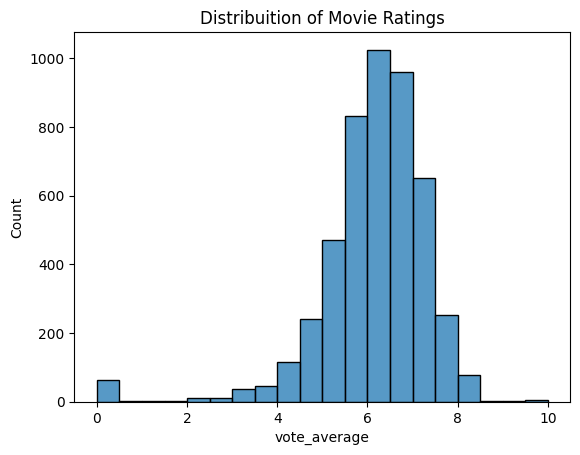

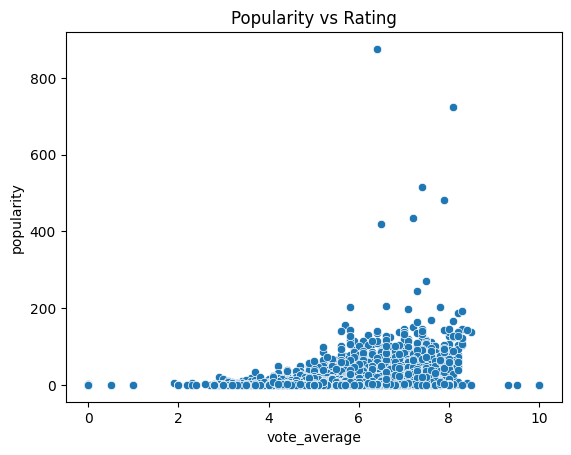

In [23]:
plt.figure()
sns.histplot(movies_data['vote_average'], bins=20)
plt.title('Distribuition of Movie Ratings')
plt.show()

plt.figure()
sns.scatterplot(x='vote_average',y='popularity',data=movies_data)
plt.title('Popularity vs Rating')
plt.show()

5. TF_IDF Feature Extraction

In [24]:
vectorizer=TfidfVectorizer(stop_words='english')
tfidf_features=vectorizer.fit_transform(combined_features)

print('\n _____TF_IDF Features Created_____')
print("TF_IDF matrix shape:", tfidf_features.shape)


 _____TF_IDF Features Created_____
TF_IDF matrix shape: (4803, 17079)


6. Cosine Similarity Matrix

In [25]:
similarity=cosine_similarity(tfidf_features)

7. One Hot Encodig (Genres)

In [26]:
encoder=OneHotEncoder(handle_unknown='ignore')
genre_encoded=encoder.fit_transform(movies_data[['genres']])

8. Numeric Feature Scaling

In [27]:
numeric_features=movies_data[['vote_average','popularity']]
scaler=StandardScaler()
numeric_scaled=scaler.fit_transform(numeric_features)

9. Combined Features

In [28]:
final_features=hstack([tfidf_features,genre_encoded,numeric_scaled])
print("_____Final Feature Matrix_____")
print("Total Feature Size:", final_features.shape)

_____Final Feature Matrix_____
Total Feature Size: (4803, 18250)


10. Create Popularity Label

In [29]:
movies_data['popular']=(movies_data['vote_average']>=movies_data['vote_average'].median()).astype(int)
labels=movies_data['popular']

11. Train Test Split

In [30]:
X_train,X_test, y_train, y_test=train_test_split(
    final_features,labels,test_size=0.2,random_state=42)

12. SVM popularity Prediction Model

In [31]:
svm_model=SVC()
svm_model.fit(X_train,y_train)
svm_predictions=svm_model.predict(X_test)

print("\n_____SVM Model Performance_____")

precision=precision_score(y_test,svm_predictions)
recall=recall_score(y_test,svm_predictions)
f1=f1_score(y_test,svm_predictions)
print("Accuracy:", accuracy_score(y_test, svm_predictions))


print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)
print(classification_report(y_test, svm_predictions))



_____SVM Model Performance_____
Accuracy: 0.9958376690946931
Precision: 0.9941860465116279
Recall: 0.9980544747081712
F1 score: 0.996116504854369
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       447
           1       0.99      1.00      1.00       514

    accuracy                           1.00       961
   macro avg       1.00      1.00      1.00       961
weighted avg       1.00      1.00      1.00       961



13. KMeans Movie Clustering

In [32]:
kmeans=KMeans(n_clusters=10,random_state=42)
clusters=kmeans.fit_predict(tfidf_features)
movies_data['clusters']=clusters
print("_____Movies Clusters Created_____")
print(movies_data[['title','clusters']].head())

_____Movies Clusters Created_____
                                      title  clusters
0                                    Avatar         6
1  Pirates of the Caribbean: At World's End         2
2                                   Spectre         2
3                     The Dark Knight Rises         3
4                               John Carter         6


14. Movie Similarity Heatmap

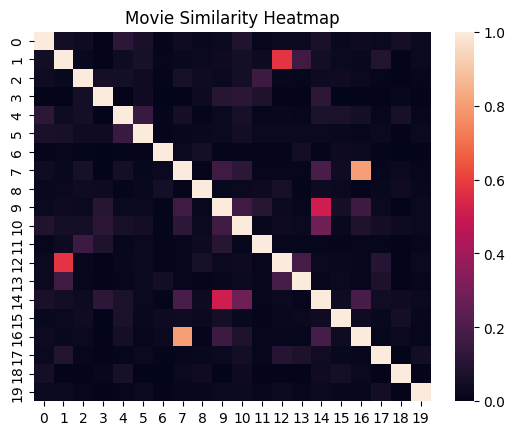

In [33]:
plt.figure()
sns.heatmap(similarity[:20,:20])
plt.title("Movie Similarity Heatmap")
plt.show()

15. Movies Recommendation System

In [34]:
def recommend_movies(movies_name):
  list_of_all_titles=movies_data['title'].tolist()
  find_close_match=difflib.get_close_matches(movies_name,list_of_all_titles)

  if(len(find_close_match)==0):
    print("Movies not found")
    return
  close_match=find_close_match[0]

  index_of_movies=movies_data[movies_data.title==close_match]['index'].values[0]
  similarity_score=list(enumerate(similarity[index_of_movies]))
  sorted_similar_movies=sorted(similarity_score,key=lambda x:x[1], reverse=True)
  print("\n _____TOP MOVIES RECOMMENDATIONS_____")
  i=1
  for movie in sorted_similar_movies:
    index=movie[0]
    title=movies_data[movies_data.index==index]['title'].values[0]
    if i<20:
      print(i,'.', title)
      i+=1

16. Genre Based Recommendation

In [35]:
def recommend_by_genre():
  genre=input("Enter a genre:")
  filtered_movies=movies_data[movies_data['genres'].str.contains(genre, case=False)]
  filtered_movies=filtered_movies.sort_values(by='vote_average', ascending=False)
  print("\n_____TOP MOVIES IN ", genre.upper(),"GENRE_____")
  print(filtered_movies[['title','vote_average']].head(10))


17. Hybrid Recommendation System

In [36]:
def hybrid_recommendation(movie_name):
  list_of_titles=movies_data['title'].tolist()
  match=difflib.get_close_matches(movie_name,list_of_titles)
  if(len(match)==0):
    print("Movie not found")
    return
  movie=match[0]
  index=movies_data[movies_data.title==movie]['index'].values[0]
  similarity_score=list(enumerate(similarity[index]))
  sorted_movies=sorted(similarity_score,key=lambda x:x[1], reverse=True)
  print("\n_____ Hybrid recommendations_____")
  i=1
  for m in sorted_movies:
    idx=m[0]
    title=movies_data[movies_data.index==idx]['title'].values[0]
    rating=movies_data[movies_data.index==idx]['vote_average'].values[0]
    popularity=movies_data[movies_data.index==idx]['popularity'].values[0]
    score=(0.5*m[1])+(0.3*rating/10)+(0.2*popularity/100)
    # Weights: content similarity matters most, rating second, popularity least
    if(i<15):
      print(i,'.',title,'Score:',round(score,3))
      i+=1

18. User Interface

In [37]:
print("\n1. Movie Based Recommendation")
print("2. Genre Based Recommendation")
print("3. Hybrid Recommendation")

choice = int(input("Enter your choice: "))

if choice == 1:

    movie_name = input("Enter your favourite movie name: ")

    recommend_movies(movie_name)

elif choice == 2:

    recommend_by_genre()

elif choice == 3:

    movie_name = input("Enter movie name: ")

    hybrid_recommendation(movie_name)


1. Movie Based Recommendation
2. Genre Based Recommendation
3. Hybrid Recommendation
Enter your choice: 1
Enter your favourite movie name: harry potter 

 _____TOP MOVIES RECOMMENDATIONS_____
1 . Party Monster
2 . Home Alone 2: Lost in New York
3 . Shattered Glass
4 . #Horror
5 . Kids
6 . Barry Munday
7 . Neighbors 2: Sorority Rising
8 . Boys Don't Cry
9 . Trees Lounge
10 . Valley of the Heart's Delight
11 . Antibirth
12 . The Game
13 . Saved!
14 . The Brown Bunny
15 . Home Alone
16 . How to Be Single
17 . Mommie Dearest
18 . Carrie
19 . What Lies Beneath
